In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

In [2]:
# Detect project root automatically
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "shopee_absa.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "shopee_absa_checked.csv"

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Processed data path:", PROCESSED_DATA_PATH)

Project root: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project
Raw data path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\raw\shopee_absa.csv
Processed data path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\shopee_absa_checked.csv


In [3]:
def load_csv_safely(file_path):
    """
    Load CSV file with common encodings.
    This helps avoid UnicodeDecodeError when reading Vietnamese text.
    """
    encodings = ["utf-8-sig", "utf-8", "cp1258", "latin1"]

    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"Loaded successfully with encoding: {encoding}")
            return df
        except UnicodeDecodeError:
            print(f"Failed with encoding: {encoding}")

    raise UnicodeDecodeError("Could not read the file with common encodings.")


df = load_csv_safely(RAW_DATA_PATH)

Loaded successfully with encoding: utf-8-sig


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (2468, 5)


In [5]:
df.head()

,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [6]:
print(df.columns.tolist())

['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca']


In [7]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['comment', 'chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca']


In [8]:
required_columns = ["comment", "chat_luong", "dong_goi", "van_chuyen", "gia_ca"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [9]:
df = df[required_columns].copy()

df.head()

,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2468 entries, 0 to 2467
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   comment     2468 non-null   str  
 1   chat_luong  2468 non-null   str  
 2   dong_goi    2468 non-null   str  
 3   van_chuyen  2468 non-null   str  
 4   gia_ca      2468 non-null   str  
dtypes: str(5)
memory usage: 96.5 KB


In [11]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_ratio"] = missing_summary["missing_count"] / len(df)

missing_summary

,column,missing_count,missing_ratio
0,comment,0,0.0
1,chat_luong,0,0.0
2,dong_goi,0,0.0
3,van_chuyen,0,0.0
4,gia_ca,0,0.0


In [12]:
duplicate_count = df.duplicated(subset=["comment"]).sum()

print("Number of duplicated comments:", duplicate_count)

Number of duplicated comments: 2


In [13]:
duplicated_comments = df[df.duplicated(subset=["comment"], keep=False)].sort_values("comment")

duplicated_comments.head(20)

,comment,chat_luong,dong_goi,van_chuyen,gia_ca
1741,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral
1929,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral
2351,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral


In [14]:
full_duplicate_count = df.duplicated().sum()

print("Number of fully duplicated rows:", full_duplicate_count)

Number of fully duplicated rows: 2


In [15]:
df[df.duplicated(keep=False)].head(20)

,comment,chat_luong,dong_goi,van_chuyen,gia_ca
1741,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral
1929,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral
2351,bình luận rác châm ngôn cuộc sống không liên quan,neutral,neutral,neutral,neutral


In [16]:
before_drop_duplicates = len(df)

df = df.drop_duplicates().copy()

after_drop_duplicates = len(df)

print("Rows before dropping full duplicates:", before_drop_duplicates)
print("Rows after dropping full duplicates:", after_drop_duplicates)
print("Removed rows:", before_drop_duplicates - after_drop_duplicates)

Rows before dropping full duplicates: 2468
Rows after dropping full duplicates: 2466
Removed rows: 2


In [17]:
aspect_columns = ["chat_luong", "dong_goi", "van_chuyen", "gia_ca"]

conflicting_comments = (
    df.groupby("comment")[aspect_columns]
    .nunique()
    .reset_index()
)

conflicting_comments["has_conflict"] = conflicting_comments[aspect_columns].gt(1).any(axis=1)

num_conflicting_comments = conflicting_comments["has_conflict"].sum()

print("Number of comments with conflicting labels:", num_conflicting_comments)

Number of comments with conflicting labels: 0


In [18]:
df["comment"] = df["comment"].astype(str).str.strip()

# Remove rows where comment becomes empty after stripping
before_empty_check = len(df)

df = df[df["comment"] != ""].copy()

after_empty_check = len(df)

print("Rows removed because comment is empty:", before_empty_check - after_empty_check)

Rows removed because comment is empty: 0


In [19]:
for col in aspect_columns:
    print(f"\nUnique labels in {col}:")
    print(df[col].unique())


Unique labels in chat_luong:
<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str

Unique labels in dong_goi:
<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str

Unique labels in van_chuyen:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Unique labels in gia_ca:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [20]:
def normalize_label(label):
    """
    Normalize sentiment labels into three standard classes:
    positive, negative, neutral.
    """
    if pd.isna(label):
        return np.nan

    label = str(label).strip().lower()

    label_mapping = {
        # positive variants
        "positive": "positive",
        "pos": "positive",
        "tích cực": "positive",
        "tich cuc": "positive",
        "tot": "positive",
        "tốt": "positive",
        "hai long": "positive",
        "hài lòng": "positive",

        # negative variants
        "negative": "negative",
        "neg": "negative",
        "tiêu cực": "negative",
        "tieu cuc": "negative",
        "xấu": "negative",
        "xau": "negative",
        "tệ": "negative",
        "te": "negative",
        "không hài lòng": "negative",
        "khong hai long": "negative",

        # neutral variants
        "neutral": "neutral",
        "neu": "neutral",
        "trung lập": "neutral",
        "trung lap": "neutral",
        "bình thường": "neutral",
        "binh thuong": "neutral",
        "không đề cập": "neutral",
        "khong de cap": "neutral",
        "none": "neutral",
        "nan": "neutral",
    }

    return label_mapping.get(label, label)

In [21]:
for col in aspect_columns:
    df[col] = df[col].apply(normalize_label)

In [22]:
valid_labels = {"positive", "negative", "neutral"}

for col in aspect_columns:
    unique_labels = set(df[col].dropna().unique())
    invalid_labels = unique_labels - valid_labels

    print(f"\nAspect: {col}")
    print("Unique labels:", sorted(unique_labels))

    if invalid_labels:
        print("Invalid labels found:", invalid_labels)
    else:
        print("All labels are valid.")


Aspect: chat_luong
Unique labels: ['negative', 'neutral', 'positive']
All labels are valid.

Aspect: dong_goi
Unique labels: ['negative', 'neutral', 'positive']
All labels are valid.

Aspect: van_chuyen
Unique labels: ['negative', 'neutral', 'positive']
All labels are valid.

Aspect: gia_ca
Unique labels: ['negative', 'neutral', 'positive']
All labels are valid.


In [23]:
final_missing_summary = df.isna().sum().reset_index()
final_missing_summary.columns = ["column", "missing_count"]
final_missing_summary["missing_ratio"] = final_missing_summary["missing_count"] / len(df)

final_missing_summary

,column,missing_count,missing_ratio
0,comment,0,0.0
1,chat_luong,0,0.0
2,dong_goi,0,0.0
3,van_chuyen,0,0.0
4,gia_ca,0,0.0


In [24]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (2466, 5)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [25]:
df.to_csv(PROCESSED_DATA_PATH, index=False, encoding="utf-8-sig")

print("Saved checked dataset to:", PROCESSED_DATA_PATH)

Saved checked dataset to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\shopee_absa_checked.csv


In [26]:
df_checked = pd.read_csv(PROCESSED_DATA_PATH, encoding="utf-8-sig")

print(df_checked.shape)
df_checked.head()

(2466, 5)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [27]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "shopee_absa_checked.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data path:", PROCESSED_DATA_PATH)
print("Results dir:", RESULTS_DIR)
print("Figures dir:", FIGURES_DIR)

Project root: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project
Processed data path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\shopee_absa_checked.csv
Results dir: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results
Figures dir: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures


In [29]:
df = pd.read_csv(PROCESSED_DATA_PATH, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2466, 5)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [30]:
aspect_columns = ["chat_luong", "dong_goi", "van_chuyen", "gia_ca"]

label_order = ["positive", "negative", "neutral"]

for col in aspect_columns:
    print(col, df[col].unique())

chat_luong <StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
dong_goi <StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
van_chuyen <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str
gia_ca <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [39]:
distribution_count = pd.DataFrame()

for aspect in aspect_columns:
    counts = df[aspect].value_counts().reindex(label_order, fill_value=0)
    distribution_count[aspect] = counts

distribution_count = distribution_count.rename_axis("label").reset_index()

distribution_count

,label,chat_luong,dong_goi,van_chuyen,gia_ca
0,positive,899,370,489,344
1,negative,1444,410,90,59
2,neutral,123,1686,1887,2063


In [40]:
distribution_count = distribution_count.reset_index()
distribution_count = distribution_count.rename(columns={"index": "label"})

distribution_count

,label,label,chat_luong,dong_goi,van_chuyen,gia_ca
0,0,positive,899,370,489,344
1,1,negative,1444,410,90,59
2,2,neutral,123,1686,1887,2063


In [42]:
distribution_ratio = pd.DataFrame()

for aspect in aspect_columns:
    ratios = df[aspect].value_counts(normalize=True).reindex(label_order, fill_value=0)
    distribution_ratio[aspect] = ratios

distribution_ratio = distribution_ratio * 100

# Đổi tên index thành "label" trước khi reset_index
distribution_ratio = distribution_ratio.rename_axis("label").reset_index()

distribution_ratio

,label,chat_luong,dong_goi,van_chuyen,gia_ca
0,positive,36.455799,15.004055,19.829684,13.949716
1,negative,58.556367,16.626115,3.649635,2.392539
2,neutral,4.987835,68.369830,76.520681,83.657745


In [43]:
distribution_ratio_rounded = distribution_ratio.copy()

for aspect in aspect_columns:
    distribution_ratio_rounded[aspect] = distribution_ratio_rounded[aspect].round(2)

distribution_ratio_rounded

,label,chat_luong,dong_goi,van_chuyen,gia_ca
0,positive,36.46,15.00,19.83,13.95
1,negative,58.56,16.63,3.65,2.39
2,neutral,4.99,68.37,76.52,83.66


In [44]:
count_output_path = RESULTS_DIR / "label_distribution_summary.csv"
ratio_output_path = RESULTS_DIR / "label_distribution_ratio.csv"

distribution_count.to_csv(count_output_path, index=False, encoding="utf-8-sig")
distribution_ratio_rounded.to_csv(ratio_output_path, index=False, encoding="utf-8-sig")

print("Saved count summary to:", count_output_path)
print("Saved ratio summary to:", ratio_output_path)

Saved count summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\label_distribution_summary.csv
Saved ratio summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\label_distribution_ratio.csv


In [45]:
distribution_long = []

for aspect in aspect_columns:
    counts = df[aspect].value_counts().reindex(label_order, fill_value=0)

    for label, count in counts.items():
        distribution_long.append({
            "aspect": aspect,
            "label": label,
            "count": count
        })

distribution_long = pd.DataFrame(distribution_long)

distribution_long

,aspect,label,count
0,chat_luong,positive,899
1,chat_luong,negative,1444
2,chat_luong,neutral,123
3,dong_goi,positive,370
4,dong_goi,negative,410
5,dong_goi,neutral,1686
6,van_chuyen,positive,489
7,van_chuyen,negative,90
8,van_chuyen,neutral,1887
9,gia_ca,positive,344


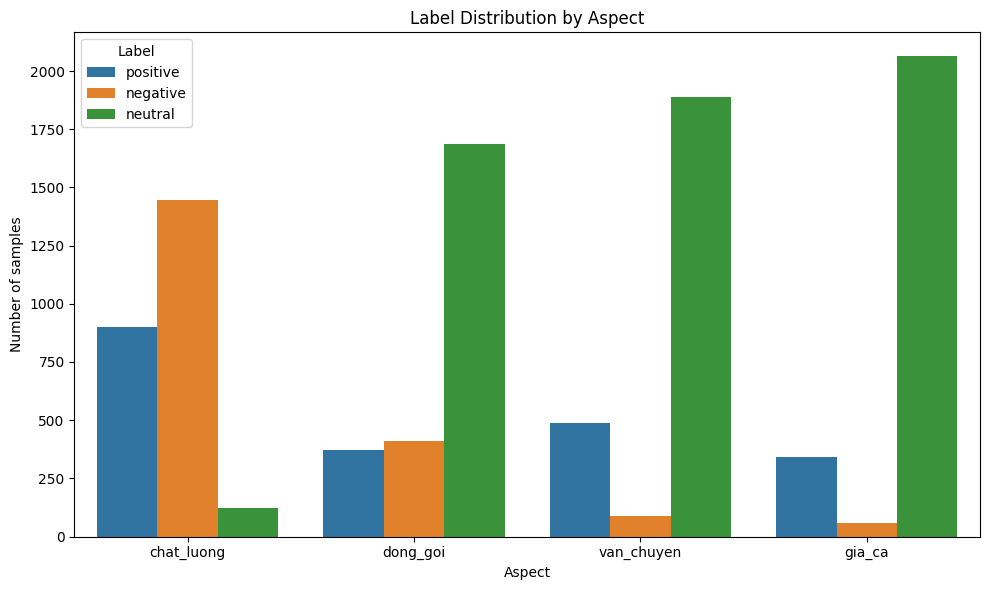

Saved figure to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures\label_distribution_count.png


In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=distribution_long,
    x="aspect",
    y="count",
    hue="label",
    hue_order=label_order
)

plt.title("Label Distribution by Aspect")
plt.xlabel("Aspect")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.tight_layout()

count_figure_path = FIGURES_DIR / "label_distribution_count.png"
plt.savefig(count_figure_path, dpi=300)
plt.show()

print("Saved figure to:", count_figure_path)

In [47]:
distribution_ratio_long = []

for aspect in aspect_columns:
    ratios = df[aspect].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100

    for label, ratio in ratios.items():
        distribution_ratio_long.append({
            "aspect": aspect,
            "label": label,
            "ratio": ratio
        })

distribution_ratio_long = pd.DataFrame(distribution_ratio_long)

distribution_ratio_long

,aspect,label,ratio
0,chat_luong,positive,36.455799
1,chat_luong,negative,58.556367
2,chat_luong,neutral,4.987835
3,dong_goi,positive,15.004055
4,dong_goi,negative,16.626115
5,dong_goi,neutral,68.369830
6,van_chuyen,positive,19.829684
7,van_chuyen,negative,3.649635
8,van_chuyen,neutral,76.520681
9,gia_ca,positive,13.949716


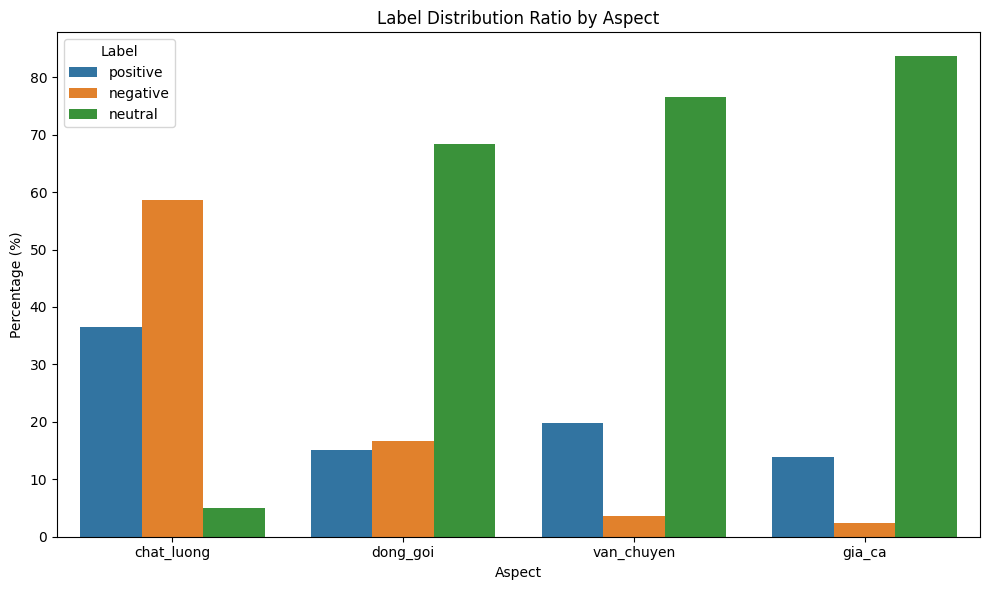

Saved figure to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures\label_distribution_ratio.png


In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=distribution_ratio_long,
    x="aspect",
    y="ratio",
    hue="label",
    hue_order=label_order
)

plt.title("Label Distribution Ratio by Aspect")
plt.xlabel("Aspect")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.tight_layout()

ratio_figure_path = FIGURES_DIR / "label_distribution_ratio.png"
plt.savefig(ratio_figure_path, dpi=300)
plt.show()

print("Saved figure to:", ratio_figure_path)

In [50]:
imbalance_summary = []

for aspect in aspect_columns:
    counts = df[aspect].value_counts().reindex(label_order, fill_value=0)

    max_count = counts.max()
    min_count = counts.min()

    if min_count == 0:
        imbalance_ratio = np.inf
    else:
        imbalance_ratio = max_count / min_count

    majority_label = counts.idxmax()
    minority_label = counts.idxmin()

    imbalance_summary.append({
        "aspect": aspect,
        "majority_label": majority_label,
        "majority_count": max_count,
        "minority_label": minority_label,
        "minority_count": min_count,
        "imbalance_ratio": imbalance_ratio
    })

imbalance_summary = pd.DataFrame(imbalance_summary)

imbalance_summary

,aspect,majority_label,majority_count,minority_label,minority_count,imbalance_ratio
0,chat_luong,negative,1444,neutral,123,11.739837
1,dong_goi,neutral,1686,positive,370,4.556757
2,van_chuyen,neutral,1887,negative,90,20.966667
3,gia_ca,neutral,2063,negative,59,34.966102


In [51]:
imbalance_summary["imbalance_ratio"] = imbalance_summary["imbalance_ratio"].round(2)

imbalance_output_path = RESULTS_DIR / "imbalance_summary.csv"
imbalance_summary.to_csv(imbalance_output_path, index=False, encoding="utf-8-sig")

print("Saved imbalance summary to:", imbalance_output_path)

imbalance_summary

Saved imbalance summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\imbalance_summary.csv


,aspect,majority_label,majority_count,minority_label,minority_count,imbalance_ratio
0,chat_luong,negative,1444,neutral,123,11.74
1,dong_goi,neutral,1686,positive,370,4.56
2,van_chuyen,neutral,1887,negative,90,20.97
3,gia_ca,neutral,2063,negative,59,34.97


In [54]:
for _, row in imbalance_summary.iterrows():
    aspect = row["aspect"]
    majority_label = row["majority_label"]
    majority_count = row["majority_count"]
    minority_label = row["minority_label"]
    minority_count = row["minority_count"]
    imbalance_ratio = row["imbalance_ratio"]

    print(f"Aspect: {aspect}")
    print(f"- Majority class: {majority_label} ({majority_count} samples)")
    print(f"- Minority class: {minority_label} ({minority_count} samples)")
    print(f"- Imbalance ratio: {imbalance_ratio}")

    if imbalance_ratio <= 2:
        print("- Comment: The label distribution is relatively balanced.")
    elif imbalance_ratio <= 5:
        print("- Comment: The label distribution shows moderate imbalance.")
    else:
        print("- Comment: The label distribution shows strong imbalance.")

    print()

Aspect: chat_luong
- Majority class: negative (1444 samples)
- Minority class: neutral (123 samples)
- Imbalance ratio: 11.74
- Comment: The label distribution shows strong imbalance.

Aspect: dong_goi
- Majority class: neutral (1686 samples)
- Minority class: positive (370 samples)
- Imbalance ratio: 4.56
- Comment: The label distribution shows moderate imbalance.

Aspect: van_chuyen
- Majority class: neutral (1887 samples)
- Minority class: negative (90 samples)
- Imbalance ratio: 20.97
- Comment: The label distribution shows strong imbalance.

Aspect: gia_ca
- Majority class: neutral (2063 samples)
- Minority class: negative (59 samples)
- Imbalance ratio: 34.97
- Comment: The label distribution shows strong imbalance.



In [55]:
from pathlib import Path
import sys

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing import clean_text, apply_text_preprocessing

In [56]:
test_comments = [
    "Giao hàng nhanhhh, shoppp đóng gói kỹ lắm!!!",
    "Sp đẹp, giá rẻ, okkkkk nha",
    "Ko đáng tiền, sản phẩm hơi mỏng",
    "Shop giao sai hàng, đóng gói móp méo quá!!!",
    "Mình mua nhận xu thôi, chưa dùng nên chưa biết chất lượng",
    "Link sản phẩm: https://shopee.vn/abc đẹp lắm nhaaaa",
]

for comment in test_comments:
    print("Original:", comment)
    print("Cleaned :", clean_text(comment))
    print("-" * 80)

Original: Giao hàng nhanhhh, shoppp đóng gói kỹ lắm!!!
Cleaned : giao hàng nhanh shop đóng gói kỹ lắm
--------------------------------------------------------------------------------
Original: Sp đẹp, giá rẻ, okkkkk nha
Cleaned : sản phẩm đẹp giá rẻ ok nha
--------------------------------------------------------------------------------
Original: Ko đáng tiền, sản phẩm hơi mỏng
Cleaned : không đáng tiền sản phẩm hơi mỏng
--------------------------------------------------------------------------------
Original: Shop giao sai hàng, đóng gói móp méo quá!!!
Cleaned : shop giao sai hàng đóng gói móp méo quá
--------------------------------------------------------------------------------
Original: Mình mua nhận xu thôi, chưa dùng nên chưa biết chất lượng
Cleaned : mình mua nhận xu thôi chưa dùng nên chưa biết chất lượng
--------------------------------------------------------------------------------
Original: Link sản phẩm: https://shopee.vn/abc đẹp lắm nhaaaa
Cleaned : link sản phẩm đẹp lắm 

In [57]:
import pandas as pd

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "shopee_absa_checked.csv"

df = pd.read_csv(PROCESSED_DATA_PATH, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2466, 5)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral
2,Bài viết JISOO...,neutral,neutral,neutral,neutral
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral
4,Sản phẩm móp méo,negative,negative,neutral,neutral


In [58]:
df = apply_text_preprocessing(df, text_column="comment")

df[["comment", "clean_comment"]].head(10)

,comment,clean_comment
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,chất lượng sản phẩm dày dặn màu tô khác hình
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",chưa dùng đóng gói cẩn thận giao nhanh
2,Bài viết JISOO...,bài viết jisoo
3,"Đẹp, màu xinh, khó tô",đẹp màu xinh khó tô
4,Sản phẩm móp méo,sản phẩm móp méo
5,Sản phẩm ok nhưng màu tối,sản phẩm ok nhưng màu tối
6,Rẻ đẹp xứng giá,rẻ đẹp xứng giá
7,Hộp móp nhưng sp ok,hộp móp nhưng sản phẩm ok
8,Bị rách nhẹ,bị rách nhẹ
9,"Giao nhanh, thiếu sơn",giao nhanh thiếu sơn


In [59]:
sample_text_check = df[["comment", "clean_comment"]].sample(10, random_state=42)

sample_text_check

,comment,clean_comment
1078,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...
1281,nan ô mỏng bằng sợi tóc. ô nhỏ chán,nan ô mỏng bằng sợi tóc ô nhỏ chán
621,giao nhanh date mới date xa,giao nhanh date mới date xa
1508,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...
1975,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...
1956,hàng fake không có mã qr check dùng lúc đầu ổn...,hàng fake không có mã qr check dùng lúc đầu ổn...
1996,chất lượng đểu mua 2 ngón giao 1 ngón,chất lượng đểu mua 2 ngón giao 1 ngón
856,2 chai dầu bị chảy rất nhiều,2 chai dầu bị chảy rất nhiều
1287,loại tự động ok loại thủ công yếu mùi hôi gió ...,loại tự động ok loại thủ công yếu mùi hôi gió ...
495,bắp mềm dẻo ngọt vừa phải ăn ngon,bắp mềm dẻo ngọt vừa phải ăn ngon


In [60]:
empty_clean_count = (df["clean_comment"].str.strip() == "").sum()

print("Number of empty clean comments:", empty_clean_count)

Number of empty clean comments: 0


In [61]:
df["clean_comment_length"] = df["clean_comment"].apply(lambda x: len(str(x).split()))

df["clean_comment_length"].describe()

count    2466.000000
mean       10.755880
std         6.232124
min         1.000000
25%         6.000000
50%        10.000000
75%        14.000000
max        44.000000
Name: clean_comment_length, dtype: float64

In [62]:
short_comments = df[df["clean_comment_length"] <= 2][
    ["comment", "clean_comment", "chat_luong", "dong_goi", "van_chuyen", "gia_ca"]
]

print("Number of very short comments:", len(short_comments))

short_comments.head(20)

Number of very short comments: 97


,comment,clean_comment,chat_luong,dong_goi,van_chuyen,gia_ca
18,Màu nhạt,màu nhạt,negative,neutral,neutral,neutral
22,Giao nhầm,giao nhầm,negative,negative,neutral,neutral
23,Cọ lỗi,cọ lỗi,negative,neutral,neutral,neutral
25,Lỗi màu,lỗi màu,negative,neutral,neutral,neutral
26,Màu khô,màu khô,negative,neutral,neutral,neutral
28,Màu xấu,màu xấu,negative,neutral,neutral,neutral
30,Rách nhẹ,rách nhẹ,negative,negative,neutral,neutral
31,Lỗi sọc,lỗi sọc,negative,neutral,neutral,neutral
32,Thiếu cọ,thiếu cọ,negative,negative,neutral,neutral
34,Khó tô,khó tô,negative,neutral,neutral,neutral


In [66]:
df = df.drop(columns=["clean_comment_length"], errors="ignore")

df.head()

,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral,chất lượng sản phẩm dày dặn màu tô khác hình
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral,chưa dùng đóng gói cẩn thận giao nhanh
2,Bài viết JISOO...,neutral,neutral,neutral,neutral,bài viết jisoo
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral,đẹp màu xinh khó tô
4,Sản phẩm móp méo,negative,negative,neutral,neutral,sản phẩm móp méo


In [64]:
PREPROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "shopee_absa_preprocessed.csv"

df.to_csv(PREPROCESSED_DATA_PATH, index=False, encoding="utf-8-sig")

print("Saved preprocessed dataset to:", PREPROCESSED_DATA_PATH)

Saved preprocessed dataset to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\data\processed\shopee_absa_preprocessed.csv


In [67]:
df_preprocessed = pd.read_csv(PREPROCESSED_DATA_PATH, encoding="utf-8-sig")

print(df_preprocessed.shape)
df_preprocessed.head()

(2466, 6)


,comment,chat_luong,dong_goi,van_chuyen,gia_ca,clean_comment
0,Chất lượng sản phẩm: dày dặn... màu tô khác hình,negative,negative,neutral,neutral,chất lượng sản phẩm dày dặn màu tô khác hình
1,"Chưa dùng... đóng gói cẩn thận, giao nhanh",positive,positive,positive,neutral,chưa dùng đóng gói cẩn thận giao nhanh
2,Bài viết JISOO...,neutral,neutral,neutral,neutral,bài viết jisoo
3,"Đẹp, màu xinh, khó tô",negative,neutral,neutral,neutral,đẹp màu xinh khó tô
4,Sản phẩm móp méo,negative,negative,neutral,neutral,sản phẩm móp méo
